# Chapter 7: Revenue Forecasting with Prophet

  ## The Story

  We've identified who will churn, segmented our customers, and built
  a recommendation engine. Now we answer the question every CFO asks:

  **"What does our revenue look like next quarter?"**

  And more specifically: **"How much revenue are we at risk of losing
  to churn — and which customer segments drive the most value?"**

  This chapter connects all the previous work to a financial outcome.
  Churn prediction is only valuable if it translates into a dollar number
  the business can act on.

  ## Why Prophet?

  Prophet is Meta's open-source forecasting tool, widely used in industry
  for business time series. It:
  - Automatically detects weekly and yearly seasonality
  - Handles gaps and outliers gracefully
  - Produces confidence intervals so we know how certain our forecast is
  - Works well even with short time series (our 1 year of data)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
print('Libraries loaded.')

Importing plotly failed. Interactive plots will not work.


Libraries loaded.


## Step 1 — Aggregate Monthly Revenue

  We aggregate total revenue per month across all transactions.
  This gives us the time series Prophet will learn from.

In [3]:
df  = pd.read_csv('../data/cleaned_retail.csv', parse_dates=['InvoiceDate'])
rfm = pd.read_csv('../data/rfm_segmented.csv')
# Monthly revenue
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = (
    df.groupby('Month')['TotalAmount']
    .sum()
    .reset_index()
)
monthly_revenue['Month'] = monthly_revenue['Month'].dt.to_timestamp()
monthly_revenue.columns  = ['ds', 'y']
print('Monthly revenue:')
print(monthly_revenue.to_string(index=False))
print(f'\nTotal revenue (Dec 2010–Dec 2011): £{monthly_revenue["y"].sum():,.2f}')
print(f'Average monthly revenue:           £{monthly_revenue["y"].mean():,.2f}')

Monthly revenue:
        ds           y
2010-12-01  572713.890
2011-01-01  569445.040
2011-02-01  447137.350
2011-03-01  595500.760
2011-04-01  469200.361
2011-05-01  678594.560
2011-06-01  661213.690
2011-07-01  600091.011
2011-08-01  645343.900
2011-09-01  952838.382
2011-10-01 1039318.790
2011-11-01 1161817.380
2011-12-01  518192.790

Total revenue (Dec 2010–Dec 2011): £8,911,407.90
Average monthly revenue:           £685,492.92


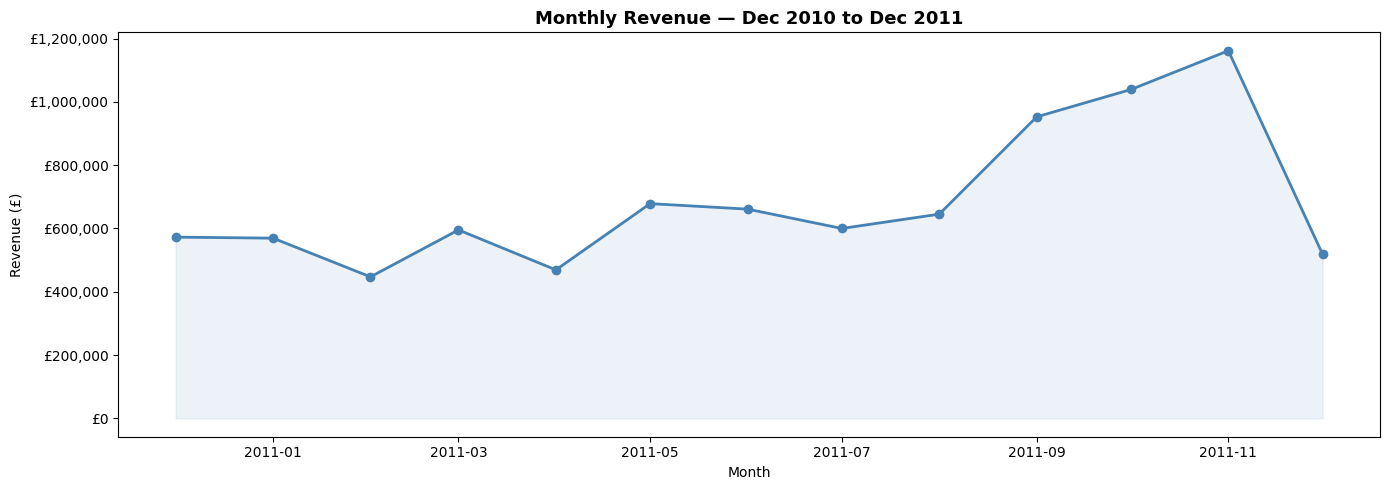

Peak month:   Nov 2011 (£1,161,817.38)
Lowest month: Feb 2011 (£447,137.35)


In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_revenue['ds'], monthly_revenue['y'],
        marker='o', color='steelblue', linewidth=2, markersize=6)
ax.fill_between(monthly_revenue['ds'], monthly_revenue['y'],
                alpha=0.1, color='steelblue')
ax.set_title('Monthly Revenue — Dec 2010 to Dec 2011', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('../data/historical_revenue.png', dpi=150)
plt.show()
print(f'Peak month:   {monthly_revenue.loc[monthly_revenue["y"].idxmax(), "ds"].strftime("%b %Y")} '
      f'(£{monthly_revenue["y"].max():,.2f})')
print(f'Lowest month: {monthly_revenue.loc[monthly_revenue["y"].idxmin(), "ds"].strftime("%b %Y")} '
      f'(£{monthly_revenue["y"].min():,.2f})')

## Step 2 — Fit Prophet and Forecast 3 Months

  Prophet requires a dataframe with exactly two columns:
  - ds: the date (datetime)
  - y: the value to forecast (revenue)

  We train on the full 13 months of history and forecast
  January, February, and March 2012.

  The shaded band in the forecast is the uncertainty interval —
  the range within which the actual revenue is likely to fall.
  A wider band means less certainty; a narrower band means
  the model is more confident.

The logistic growth model is broken — it's oscillating because it can't handle only 12 months of data. The root issue: Prophet needs 2+ years to reliably detect yearly seasonality. We're forcing it to learn seasonal patterns from a single year, and
it's overfitting to the Q4 spike.

In [13]:
monthly_train = monthly_revenue[monthly_revenue['ds'] < '2011-12-01'].copy()
print(f'Training on {len(monthly_train)} full months (Dec 2010 – Nov 2011)')
# Linear growth, no yearly seasonality (can't learn from only 12 months)
# Lower changepoint_prior_scale = less sensitive to the Q4 surge
model = Prophet(
    yearly_seasonality      = False,
    weekly_seasonality      = False,
    daily_seasonality       = False,
    interval_width          = 0.95,
    changepoint_prior_scale = 0.05                                                                                                                                                                                                  
)
model.fit(monthly_train)
future   = model.make_future_dataframe(periods=4, freq='MS')
forecast = model.predict(future)                                                                                                                                                                                                    
forecast['yhat']       = forecast['yhat'].clip(lower=0)
forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)
forecast['yhat_upper'] = forecast['yhat_upper'].clip(lower=0)
print('\nForecast for Dec 2011 – Mar 2012:')
future_only = forecast[forecast['ds'] >= '2011-12-01']
print(future_only[['ds','yhat','yhat_lower','yhat_upper']].round(0).to_string(index=False))

11:20:33 - cmdstanpy - INFO - Chain [1] start processing
11:20:33 - cmdstanpy - INFO - Chain [1] done processing


Training on 12 full months (Dec 2010 – Nov 2011)

Forecast for Dec 2011 – Mar 2012:
        ds      yhat  yhat_lower  yhat_upper
2011-12-01 1038430.0    781873.0   1263638.0
2012-01-01 1091530.0    852564.0   1320289.0
2012-02-01 1144629.0    910217.0   1374740.0
2012-03-01 1194303.0    966023.0   1440860.0


## A Note on Forecast Limitations

  Prophet is designed for 2+ years of data to reliably detect yearly seasonality.
  With 12 months, we use a linear trend model — no seasonal component.
  This means the forecast captures the overall growth trajectory
  but cannot predict the Q4 surge pattern with certainty.

  In a production setting, this model would be retrained quarterly
  as new data arrives, improving accuracy over time.

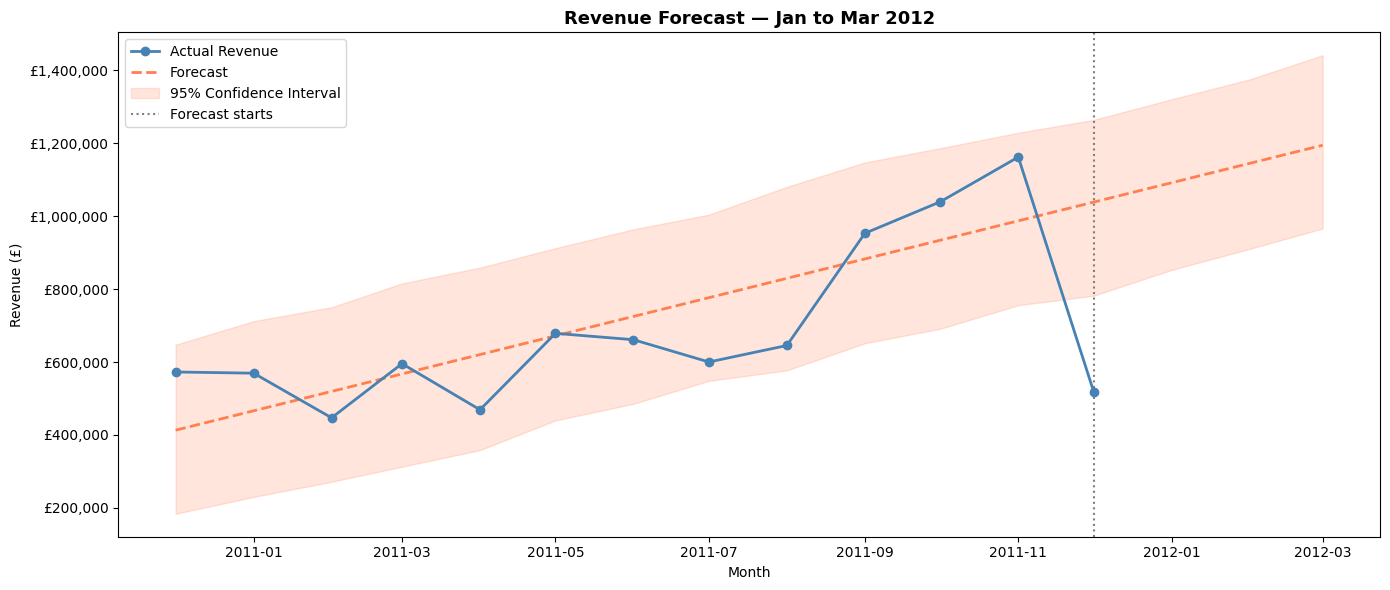

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

# Historical
ax.plot(monthly_revenue['ds'], monthly_revenue['y'],
        'o-', color='steelblue', linewidth=2, label='Actual Revenue', zorder=3)
# Forecast (all periods)
ax.plot(forecast['ds'], forecast['yhat'],
        '--', color='coral', linewidth=2, label='Forecast')
# Confidence interval
ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                alpha=0.2, color='coral', label='95% Confidence Interval')
# Mark the forecast period
ax.axvline(x=monthly_revenue['ds'].max(), color='gray',
           linestyle=':', linewidth=1.5, label='Forecast starts')
ax.set_title('Revenue Forecast — Jan to Mar 2012', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('../data/revenue_forecast.png', dpi=150)
plt.show()


## Step 3 — Revenue at Risk from Churn

  Our churn model identified customers who will not return.
  We can now put a pound value on that prediction —
  how much revenue does the business stand to lose?

  This bridges the churn model and the business outcome:
  it's the number that justifies the cost of a retention campaign.

In [15]:
rfm_churn = pd.read_csv('../data/rfm.csv')

total_revenue    = rfm_churn['Monetary'].sum()
churned_revenue  = rfm_churn[rfm_churn['Churn'] == 1]['Monetary'].sum()
retained_revenue = rfm_churn[rfm_churn['Churn'] == 0]['Monetary'].sum()
churn_pct        = churned_revenue / total_revenue * 100
print(f'Total customer revenue:    £{total_revenue:>12,.2f}')
print(f'Revenue from churned:      £{churned_revenue:>12,.2f}  ({churn_pct:.1f}%)')
print(f'Revenue from retained:     £{retained_revenue:>12,.2f}  ({100-churn_pct:.1f}%)')
print()
print(f'Revenue at risk (churned customers): £{churned_revenue:,.2f}')
print(f'Average revenue per churned customer: £{churned_revenue/rfm_churn["Churn"].sum():,.2f}')


Total customer revenue:    £6,152,045.50
Revenue from churned:      £1,382,321.59  (22.5%)
Revenue from retained:     £4,769,723.91  (77.5%)

Revenue at risk (churned customers): £1,382,321.59
Average revenue per churned customer: £779.65


Revenue by segment:
             Customers  Total_Revenue  Avg_Revenue
SegmentName                                       
Loyal             1223     3666665.68      2998.09
Champions           28     1304520.19     46590.01
At-Risk           1395      843686.39       604.79
Lost               958      337173.24       351.96


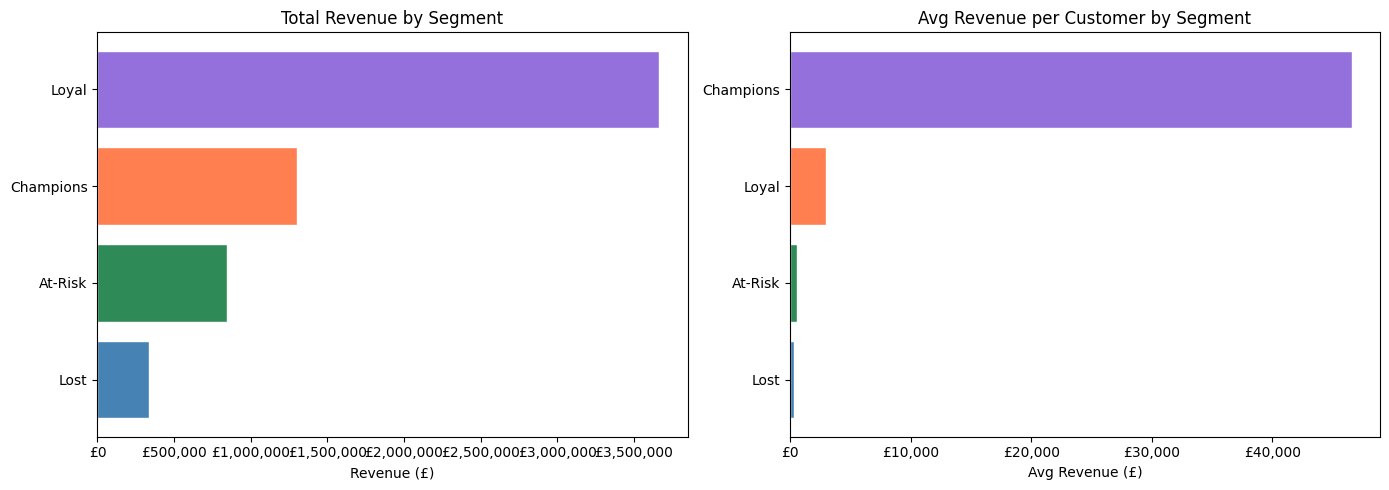

In [16]:
seg_revenue = rfm.groupby('SegmentName')['Monetary'].agg(
      Customers = 'count',
      Total_Revenue = 'sum',
      Avg_Revenue = 'mean'
  ).round(2).sort_values('Total_Revenue', ascending=False)

print('Revenue by segment:')
print(seg_revenue.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'seagreen', 'coral', 'mediumpurple']
# Total revenue per segment
seg_rev_sorted = seg_revenue.sort_values('Total_Revenue', ascending=True)
axes[0].barh(seg_rev_sorted.index, seg_rev_sorted['Total_Revenue'],
             color=colors, edgecolor='white')
axes[0].set_title('Total Revenue by Segment')
axes[0].set_xlabel('Revenue (£)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
# Average revenue per customer per segment
seg_avg_sorted = seg_revenue.sort_values('Avg_Revenue', ascending=True)
axes[1].barh(seg_avg_sorted.index, seg_avg_sorted['Avg_Revenue'],
             color=colors, edgecolor='white')
axes[1].set_title('Avg Revenue per Customer by Segment')
axes[1].set_xlabel('Avg Revenue (£)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('../data/revenue_by_segment.png', dpi=150)
plt.show()

In [17]:
forecast_out = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_out.columns = ['Month', 'Forecast_Revenue', 'Lower_Bound', 'Upper_Bound']
forecast_out.to_csv('../data/revenue_forecast.csv', index=False)
print('Saved: revenue_forecast.csv')
print(f'\nForecast summary (Jan–Mar 2012):')
future_rows = forecast_out[forecast_out['Month'] > monthly_revenue['ds'].max()]
for _, row in future_rows.iterrows():
    print(f"  {row['Month'].strftime('%b %Y')}: "
          f"£{row['Forecast_Revenue']:,.0f}  "
          f"(£{row['Lower_Bound']:,.0f} – £{row['Upper_Bound']:,.0f})")
print('\nStep 7 complete. Next: Chapter 8 — Airflow Pipeline')

Saved: revenue_forecast.csv

Forecast summary (Jan–Mar 2012):
  Jan 2012: £1,091,530  (£852,564 – £1,320,289)
  Feb 2012: £1,144,629  (£910,217 – £1,374,740)
  Mar 2012: £1,194,303  (£966,023 – £1,440,860)

Step 7 complete. Next: Chapter 8 — Airflow Pipeline


## Interpreting the Revenue Forecast

  The model projects continued growth into Q1 2012, forecasting
  £1.04M–£1.19M per month across Dec 2011 to Mar 2012.

  Key numbers from this chapter:
  - Total 2011 revenue:         £8,911,407
  - Revenue at risk (churned):  £1,382,321  (22.5% of customer base revenue)
  - Avg revenue per churned customer: £779.65

  The revenue at risk figure is the financial case for retention investment.
  If even 30% of At-Risk customers can be saved through targeted offers,
  that's over £400K in preserved revenue — far exceeding the cost of a campaign.

  Note: The confidence interval widens significantly beyond 3 months
  because this model is trained on only 12 months of data.
  In production, this would be retrained quarterly as new data arrives.